# Experimento 7 — Misma técnica del experimento 6, variando los modelos

Clasificación de sentimiento de reseñas — Parte 1 (ML clásico). Aprendizaje de Máquina 2026-20, Universidad de los Andes.

Este notebook continúa `experimento6.ipynb`. La sección 1 repite de forma resumida la configuración común (misma
semilla, mismo split y mismos folds). Los experimentos anteriores **no se vuelven a ejecutar**: sus métricas se
registran como valores fijos tomados de sus notebooks.

**Contenido**
1. Configuración común (resumen)
2. Experimento 7 — Variación de los modelos de nivel 1 y nivel 2

## 1. Configuración común (resumen)

### 1.1 Librerías, semilla y datos

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.base import clone

SEED = 42
np.random.seed(SEED)

CLASES = ["negativo", "neutral", "positivo"]

pd.set_option("display.max_colwidth", 200)
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.axisbelow": True,
})

train = pd.read_csv("train.csv").copy()
eval_df = pd.read_csv("eval.csv").copy()
sample_submission = pd.read_csv("sample_submission.csv")
conteo = train["label"].value_counts().reindex(CLASES)

print("train:", train.shape, "| eval:", eval_df.shape)

train: (12000, 3) | eval: (3000, 2)


### 1.2 Normalización base

La misma función de `experimento1.ipynb` (sección 2): reparar mojibake, minúsculas, quitar tildes conservando la ñ,
reducir letras repetidas 3+ veces a 2 y colapsar espacios. Conserva stopwords y puntuación.

In [2]:
TILDES = str.maketrans("áéíóúàèìòùäëïöüâêîôû", "aeiouaeiouaeiouaeiou")
PATRON_MOJIBAKE = re.compile(r"Ã[\x80-\xbf]")
PATRON_REPETIDAS = re.compile(r"([a-zñ])\1{2,}")


def reparar_mojibake(texto):
    return PATRON_MOJIBAKE.sub(lambda m: m.group().encode("latin-1").decode("utf-8"), texto)


def normalizar_texto(texto):
    texto = reparar_mojibake(texto)
    texto = texto.lower()
    texto = texto.translate(TILDES)
    texto = PATRON_REPETIDAS.sub(r"\1\1", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


train["text_norm"] = train["text"].map(normalizar_texto)
eval_df["text_norm"] = eval_df["text"].map(normalizar_texto)

### 1.3 Validación y métricas

Split 80/20 estratificado (el 20 % es el test hold-out, que solo se reporta) y CV estratificada de 5 folds sobre el
80 %. Se decide con accuracy (métrica de Kaggle) y se reporta F1 macro como control.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    train["text_norm"], train["label"], test_size=0.20, stratify=train["label"], random_state=SEED
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = {"accuracy": "accuracy", "f1_macro": "f1_macro"}

print(f"Entrenamiento + validación: {len(X_train):,}  |  Test: {len(X_test):,}")

Entrenamiento + validación: 9,600  |  Test: 2,400


### 1.4 Funciones auxiliares

Las mismas de `experimento1.ipynb` (sección 3.2 y 4.3).

In [4]:
# Métricas del experimento 1 tomadas de experimento1.ipynb (no se vuelve a ejecutar aquí)
REFERENCIA_E1 = {
    "experimento": 1,
    "descripcion": "Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",
    "mejores_params": {"clf__C": 10},
    "acc_train": 0.9973,
    "acc_cv": 0.7364,
    "std_cv": 0.0128,
    "f1_cv": 0.7478,
    "acc_test": 0.7238,
    "f1_test": 0.7366,
    "envio": "submission_01.csv",
    "kaggle_publico": None,
    "acc_neg_vs_pos_test": 0.607,
}

resultados = [{k: v for k, v in REFERENCIA_E1.items() if k != "acc_neg_vs_pos_test"}]


def contiene(serie, patron):
    """Serie booleana: True si el texto contiene el patrón."""
    return serie.map(lambda t: re.search(patron, t) is not None)


def tabla_cv(busqueda):
    """Resultados de un GridSearchCV ordenados por accuracy de validación."""
    cv = pd.DataFrame(busqueda.cv_results_)
    tabla = pd.DataFrame({
        "params": cv["params"],
        "acc_train": cv["mean_train_accuracy"],
        "acc_cv": cv["mean_test_accuracy"],
        "std_cv": cv["std_test_accuracy"],
        "f1_cv": cv["mean_test_f1_macro"],
        "seg_ajuste": cv["mean_fit_time"],
    })
    return tabla.sort_values("acc_cv", ascending=False).round(4)


def evaluar_en_test(modelo, titulo):
    """Accuracy, F1 macro, reporte por clase y matriz de confusión sobre el test (hold-out)."""
    pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="macro")
    print(f"Test -> accuracy: {acc:.4f} | F1 macro: {f1:.4f}\n")
    print(classification_report(y_test, pred, labels=CLASES, digits=3))

    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=CLASES, cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(f"Matriz de confusión en test\n{titulo}")
    ax.set_xlabel("Clase predicha")
    ax.set_ylabel("Clase real")
    ax.grid(False)
    plt.show()
    return {"acc_test": acc, "f1_test": f1, "pred": pred}


def registrar_resultado(experimento, descripcion, busqueda, metricas_test, envio=None, kaggle_publico=None):
    """Agrega a la tabla de resultados el mejor modelo de un GridSearchCV."""
    i = busqueda.best_index_
    cv = busqueda.cv_results_
    resultados.append({
        "experimento": experimento,
        "descripcion": descripcion,
        "mejores_params": busqueda.best_params_,
        "acc_train": round(cv["mean_train_accuracy"][i], 4),
        "acc_cv": round(cv["mean_test_accuracy"][i], 4),
        "std_cv": round(cv["std_test_accuracy"][i], 4),
        "f1_cv": round(cv["mean_test_f1_macro"][i], 4),
        "acc_test": round(metricas_test["acc_test"], 4),
        "f1_test": round(metricas_test["f1_test"], 4),
        "envio": envio,
        "kaggle_publico": kaggle_publico,
    })
    return pd.DataFrame(resultados)


def generar_envio(busqueda, numero):
    """Reentrena la mejor configuración con las 12.000 reseñas, predice eval y guarda envío y modelo."""
    modelo = clone(busqueda.best_estimator_)
    modelo.fit(train["text_norm"], train["label"])

    envio = pd.DataFrame({"id": eval_df["id"], "answer": modelo.predict(eval_df["text_norm"])})

    assert list(envio.columns) == ["id", "answer"]
    assert len(envio) == len(sample_submission) == 3000
    assert set(envio["id"]) == set(sample_submission["id"])
    assert set(envio["answer"]) <= set(CLASES)

    Path("envios").mkdir(exist_ok=True)
    Path("modelos").mkdir(exist_ok=True)
    ruta_envio = f"envios/submission_{numero:02d}.csv"
    ruta_modelo = f"modelos/modelo_{numero:02d}.joblib"
    envio.to_csv(ruta_envio, index=False)
    joblib.dump(modelo, ruta_modelo)

    print(f"Envío guardado en {ruta_envio} y modelo en {ruta_modelo}")
    print("Distribución de predicciones en eval (%):")
    print((envio["answer"].value_counts(normalize=True).reindex(CLASES) * 100).round(1).to_string())
    return envio


def top_coeficientes(modelo, n=15):
    """N-gramas con mayor coeficiente por clase."""
    nombres = modelo.named_steps["tfidf"].get_feature_names_out()
    clf = modelo.named_steps["clf"]
    tabla = {}
    for k, clase in enumerate(clf.classes_):
        orden = clf.coef_[k].argsort()[::-1][:n]
        tabla[clase] = [f"{nombres[i]} ({clf.coef_[k][i]:.2f})" for i in orden]
    return pd.DataFrame(tabla)[CLASES]

In [5]:
# Métricas de los experimentos 2 a 6 tomadas de sus notebooks (no se vuelven a ejecutar aquí)
for fila in [
    {"experimento": 2, "descripcion": "TF-IDF (1,2) de texto completo + última oración + tras el último conector + LR",
     "mejores_params": {"clf__C": 10}, "acc_train": 0.9999, "acc_cv": 0.8865, "std_cv": 0.0099, "f1_cv": 0.8908,
     "acc_test": 0.8992, "f1_test": 0.9031, "envio": "submission_02.csv", "kaggle_publico": 0.88},
    {"experimento": 3, "descripcion": "TF-IDF (1,2) de texto completo + oraciones con conector conclusivo + LR (sin posición)",
     "mejores_params": {"clf__C": 10}, "acc_train": 0.9980, "acc_cv": 0.7978, "std_cv": 0.0146, "f1_cv": 0.8064,
     "acc_test": 0.7963, "f1_test": 0.8054, "envio": "submission_03.csv", "kaggle_publico": None},
    {"experimento": 4, "descripcion": "Texto completo + última oración con opinión (detector) + tras conector sin evasivas, LinearSVC",
     "mejores_params": {"clf": "LinearSVC", "clf__C": 0.2}, "acc_train": 0.9770, "acc_cv": 0.9009, "std_cv": 0.0057,
     "f1_cv": 0.9055, "acc_test": 0.8975, "f1_test": 0.9021, "envio": "submission_04.csv", "kaggle_publico": None},
    {"experimento": 5, "descripcion": "Como el exp. 4, con el detector de opinión aplicado a la oración sin su conector inicial",
     "mejores_params": {"clf": "LinearSVC", "clf__C": 0.2}, "acc_train": 0.9773, "acc_cv": 0.9022, "std_cv": 0.0080,
     "f1_cv": 0.9068, "acc_test": 0.9021, "f1_test": 0.9068, "envio": "submission_05.csv", "kaggle_publico": None},
    {"experimento": 6, "descripcion": "Dos niveles: modelo del exp. 5 + polaridad por oración (cross-fitting) -> HistGradientBoosting",
     "mejores_params": {"nivel2": "hgb"}, "acc_train": 0.9392, "acc_cv": 0.9039, "std_cv": 0.0102,
     "f1_cv": 0.9085, "acc_test": 0.9150, "f1_test": 0.9191, "envio": "submission_06.csv", "kaggle_publico": 0.90},
]:
    resultados.append(fila)

# Accuracy por fold del experimento 6 (mismos folds; experimento6.ipynb, sección 2.3)
ACC_FOLDS_E6 = np.array([0.9083, 0.8969, 0.9120, 0.9146, 0.8875])

ROBUSTEZ_TEST_REF = pd.DataFrame([
    {"modelo": "Exp. 2", "escenario": "Original", "accuracy": 0.8992},
    {"modelo": "Exp. 2", "escenario": "Oraciones desordenadas", "accuracy": 0.6858},
    {"modelo": "Exp. 2", "escenario": "Última oración al inicio", "accuracy": 0.5742},
    {"modelo": "Exp. 6", "escenario": "Original", "accuracy": 0.9150},
    {"modelo": "Exp. 6", "escenario": "Oraciones desordenadas", "accuracy": 0.7354},
    {"modelo": "Exp. 6", "escenario": "Última oración al inicio", "accuracy": 0.5921},
])
pd.DataFrame(resultados)

,experimento,descripcion,mejores_params,acc_train,acc_cv,std_cv,f1_cv,acc_test,f1_test,envio,kaggle_publico
0,1,"Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",{'clf__C': 10},0.9973,0.7364,0.0128,0.7478,0.7238,0.7366,submission_01.csv,NaN
1,2,"TF-IDF (1,2) de texto completo + última oración + tras el último conector + LR",{'clf__C': 10},0.9999,0.8865,0.0099,0.8908,0.8992,0.9031,submission_02.csv,0.88
2,3,"TF-IDF (1,2) de texto completo + oraciones con conector conclusivo + LR (sin posición)",{'clf__C': 10},0.9980,0.7978,0.0146,0.8064,0.7963,0.8054,submission_03.csv,NaN
3,4,"Texto completo + última oración con opinión (detector) + tras conector sin evasivas, LinearSVC","{'clf': 'LinearSVC', 'clf__C': 0.2}",0.9770,0.9009,0.0057,0.9055,0.8975,0.9021,submission_04.csv,NaN
4,5,"Como el exp. 4, con el detector de opinión aplicado a la oración sin su conector inicial","{'clf': 'LinearSVC', 'clf__C': 0.2}",0.9773,0.9022,0.0080,0.9068,0.9021,0.9068,submission_05.csv,NaN
5,6,Dos niveles: modelo del exp. 5 + polaridad por oración (cross-fitting) -> HistGradientBoosting,{'nivel2': 'hgb'},0.9392,0.9039,0.0102,0.9085,0.9150,0.9191,submission_06.csv,0.90


## 2. Experimento 7 — Variación de los modelos de nivel 1 y nivel 2

**Motivación:** el experimento 6 (modelo en dos niveles) es el mejor hasta ahora (0,9039 en CV, 0,915 en test) y
obtuvo ≈ 0,90 en el leaderboard público, mientras que el primer puesto tiene 0,91. Su arquitectura tiene tres lugares
donde se elige un clasificador, y en el experimento 6 solo se compararon dos opciones para uno de ellos.

**Objetivo:** mantener la técnica del experimento 6 (mismas partes, mismo detector, mismas features, mismo
cross-fitting) y **variar sistemáticamente los modelos**:

| Lugar | Experimento 6 | Qué se prueba aquí |
|---|---|---|
| **Nivel 1 — modelo(s) base** | LinearSVC | LinearSVC, regresión logística, y **combinaciones** de varios modelos base (LinearSVC + LR, LinearSVC + LR + ComplementNB) |
| **Nivel 2 — combinador** | HistGradientBoosting | variantes de HGB, **regresión logística regularizada (L2, L1, elastic net)**, SVM con kernel RBF, Random Forest, Extra Trees, KNN, y ensambles por votación |

**Por qué combinar varios modelos base:** en stacking suele ayudar más usar modelos **distintos** que elegir uno
solo, porque se equivocan en reseñas diferentes y el combinador puede aprovechar esa diversidad.

**Cómo se compara de forma justa y viable:** calcular las features de nivel 1 es lo costoso (cada fold requiere
entrenar el detector y los modelos de texto seis veces por el cross-fitting). Por eso se calculan **una sola vez por
fold** y se guardan; luego todos los combinadores se entrenan y evalúan sobre **exactamente las mismas features y los
mismos folds**. El procedimiento es el mismo del experimento 6: las features de entrenamiento de cada fold se calculan
con cross-fitting interno y las de validación con modelos entrenados en el fold de entrenamiento completo.

### 2.1 Definiciones

Las mismas funciones y el mismo transformador `PartesE5` de `experimento5.ipynb` (sección 2.1).

In [6]:
from collections import Counter

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.svm import LinearSVC

PATRON_ORACIONES = re.compile(r"(?<=[.!?;])\s+")
PATRON_CONECTOR = (
    r"\b(pero|aunque|sin embargo|aun asi|en cambio|por otro lado|al final|en fin|eso si|"
    r"no obstante|de todas formas|con todo|ahora bien)\b"
)
EVASIVAS = (
    r"^(y |aun asi,? |igual,? |en fin,? )?(cada quien|todavia no me|ni lo mejor|ni tan bueno|ni tan malo|"
    r"sigo con dudas|hay de todo|para gustos|ni |no sabria|asi que ahi|queda a criterio|lo dejo a|sopesalo|"
    r"tengo sentimientos encontrados|ahi lo dejo|ahi queda|uno termina|que cada uno|juzguen ustedes|"
    r"no se que pensar|aun no me decido|no me termino de decidir|nos quedamos con eso|no me decido)"
    r"|sigo con dudas|no me termino de decidir|sentimientos encontrados"
)
CONCLUSIVOS = r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|en fin|igual|ahora|no obstante)\b"
CONCESIVOS = r"^(y )?(para ser|he de decir|la verdad|por cierto|de paso|por otro lado|ademas|eso si)\b"
CONECTOR_INICIAL = (
    r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|en fin|igual|ahora|no obstante|"
    r"para ser (honesto|honesta|sincero|sincera)|he de decir( que)?|la verdad( es que)?|por cierto|de paso|"
    r"por otro lado|ademas|eso si|sinceramente|para mi)\b[,:]?\s*"
)


def dividir_oraciones(texto):
    oraciones = [o.strip() for o in PATRON_ORACIONES.split(texto) if o.strip()]
    return oraciones or [texto]


def tras_ultimo_conector(texto):
    coincidencias = list(re.finditer(PATRON_CONECTOR, texto))
    return texto[coincidencias[-1].start():] if coincidencias else dividir_oraciones(texto)[-1]


def es_evasiva(oracion):
    return re.search(EVASIVAS, oracion) is not None


def sin_evasivas(texto):
    oraciones = dividir_oraciones(texto)
    return [o for o in oraciones if not es_evasiva(o)] or oraciones


def quitar_conector(oracion):
    """Elimina el conector inicial ('aun asi, ...', 'la verdad, ...') para quedarse con el contenido."""
    return re.sub(CONECTOR_INICIAL, "", oracion)


def tipo_conector(oracion):
    if re.match(CONCLUSIVOS, oracion):
        return "tipoconclusivo"
    if re.match(r"^(y )?eso si\b", oracion):
        return "tipoesosi"
    if re.match(CONCESIVOS, oracion):
        return "tipoconcesivo"
    return "tiponinguno"


def tfidf_palabras(min_df=2):
    return TfidfVectorizer(ngram_range=(1, 2), min_df=min_df, sublinear_tf=True)


class PartesE5(BaseEstimator, TransformerMixin):
    """Partes de la reseña con un detector de opinión entrenado en fit(). Variantes:

    - umbral: probabilidad mínima para considerar que una oración tiene opinión
    - quitar: quitar el conector inicial antes de pasar la oración al detector
    - pos_ultimas: agregar como ejemplos "con opinión" las últimas oraciones no evasivas de reseñas negativo/positivo
    - marcar_tipo: anteponer a la última oración con opinión un token con el tipo de su conector
    - penultima: agregar la penúltima oración con opinión como parte adicional
    """

    def __init__(self, umbral=0.5, quitar=False, pos_ultimas=False, marcar_tipo=False, penultima=False):
        self.umbral = umbral
        self.quitar = quitar
        self.pos_ultimas = pos_ultimas
        self.marcar_tipo = marcar_tipo
        self.penultima = penultima

    def _prep(self, oracion):
        return quitar_conector(oracion) if self.quitar else oracion

    def fit(self, X, y):
        con_opinion, sin_opinion = [], []
        for texto, etiqueta in zip(X, y):
            oraciones = dividir_oraciones(texto)
            if etiqueta == "neutral":
                sin_opinion.extend(oraciones)
                continue
            for oracion in oraciones:
                if (re.match(CONCLUSIVOS, oracion) or re.match(CONCESIVOS, oracion)) and not es_evasiva(oracion):
                    con_opinion.append(oracion)
            if self.pos_ultimas:
                ultima = sin_evasivas(texto)[-1]
                if len(ultima.split()) >= 6:
                    con_opinion.append(ultima)
        self.detector_ = Pipeline([
            ("tfidf", tfidf_palabras()),
            ("clf", LogisticRegression(C=1, max_iter=3000, class_weight="balanced", random_state=SEED)),
        ]).fit([self._prep(o) for o in con_opinion + sin_opinion], [1] * len(con_opinion) + [0] * len(sin_opinion))
        return self

    def opiniones(self, texto):
        """Oraciones no evasivas que el detector considera con opinión (en orden)."""
        candidatas = sin_evasivas(texto)
        prob = self.detector_.predict_proba([self._prep(o) for o in candidatas])[:, 1]
        con_opinion = [o for o, p in zip(candidatas, prob) if p >= self.umbral]
        return con_opinion or [candidatas[-1]]

    def transform(self, X):
        filas = []
        for texto in X:
            ops = self.opiniones(texto)
            ultima = ops[-1]
            fila = {
                "texto": texto,
                "ultima_op": (tipo_conector(ultima) + " " + ultima) if self.marcar_tipo else ultima,
                "tras_sin_ev": tras_ultimo_conector(" ".join(sin_evasivas(texto))),
            }
            if self.penultima:
                fila["penultima_op"] = ops[-2] if len(ops) > 1 else ""
            filas.append(fila)
        return pd.DataFrame(filas)


def pipeline_e5(clf=None, **variante):
    columnas = ["texto", "ultima_op", "tras_sin_ev"] + (["penultima_op"] if variante.get("penultima") else [])
    return Pipeline([
        ("partes", PartesE5(**variante)),
        ("tfidf", ColumnTransformer([(c, tfidf_palabras(), c) for c in columnas])),
        ("clf", clf if clf is not None else LinearSVC(C=0.2, max_iter=5000, random_state=SEED)),
    ])


mascara_np = (y_train != "neutral").to_numpy()
y_np = y_train.to_numpy()
termina_evasiva = X_train.map(lambda t: es_evasiva(dividir_oraciones(t)[-1])).to_numpy()

### 2.2 Nivel 1 compartido y caché de features

`fit_nivel1` entrena una sola vez el detector de opinión y el TF-IDF por partes, y sobre esa misma representación
entrena los tres modelos base (LinearSVC `C = 0,2`, regresión logística `C = 1` y ComplementNB `alpha = 0,3`) y el
modelo de polaridad de oraciones. `features_nivel1` devuelve, por bloques, los puntajes de cada modelo base y las 14
features estructurales del experimento 6 (polaridades de las últimas opiniones, evasiva, grupos de conector...).

La celda de caché tarda ≈ 15 minutos.

In [7]:
import time

from joblib import Parallel, delayed
from sklearn.base import ClassifierMixin
from sklearn.ensemble import (ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier,
                              VotingClassifier)
from sklearn.naive_bayes import ComplementNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

NOMBRES_GRUPO = ["conclusivo", "secundario", "esosi", "ninguno"]
GRUPOS = {
    "conclusivo": r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|no obstante|en fin|igual|ahora)\b",
    "secundario": r"^(y )?(de paso|por cierto|por otro lado|ademas)\b",
    "esosi": r"^(y )?(eso si|la verdad)\b",
}
COLUMNAS_PARTES = ["texto", "ultima_op", "tras_sin_ev"]


def grupo_conector(oracion):
    for g, patron in GRUPOS.items():
        if re.match(patron, oracion):
            return g
    return "ninguno"


def fit_nivel1(X, y):
    """Detector + TF-IDF por partes compartidos; tres modelos base y un modelo de polaridad de oraciones."""
    partes = PartesE5(quitar=True).fit(X, y)
    D = partes.transform(X)
    tfidf = ColumnTransformer([(c, tfidf_palabras(), c) for c in COLUMNAS_PARTES]).fit(D)
    M = tfidf.transform(D)
    bases = {
        "svc": LinearSVC(C=0.2, max_iter=5000, random_state=SEED).fit(M, y),
        "lr": LogisticRegression(C=1, max_iter=4000, random_state=SEED).fit(M, y),
        "cnb": ComplementNB(alpha=0.3).fit(M, y),
    }
    y = np.asarray(y)
    es_np = y != "neutral"
    ultimas = [quitar_conector(partes.opiniones(t)[-1]) for t, m in zip(X, es_np) if m]
    polaridad = Pipeline([
        ("tfidf", tfidf_palabras()),
        ("clf", LogisticRegression(C=3, max_iter=3000, random_state=SEED)),
    ]).fit(ultimas, y[es_np])
    return partes, tfidf, bases, polaridad


def features_nivel1(X, nivel1):
    """Features de nivel 2 por bloques: puntajes de cada modelo base + 14 features estructurales."""
    partes, tfidf, bases, polaridad = nivel1
    M = tfidf.transform(partes.transform(X))
    bloques = {
        "svc": bases["svc"].decision_function(M),
        "lr": bases["lr"].predict_log_proba(M),
        "cnb": bases["cnb"].predict_log_proba(M),
    }
    estructura = []
    for texto in X:
        ops = partes.opiniones(texto)
        pols = list(polaridad.decision_function([quitar_conector(o) for o in ops[-3:]]))
        pols = [0.0] * (3 - len(pols)) + pols
        g_ult = grupo_conector(ops[-1])
        g_pen = grupo_conector(ops[-2]) if len(ops) > 1 else "ninguno"
        fila = pols + [len(ops), float(es_evasiva(dividir_oraciones(texto)[-1])), float(pols[-1] * pols[-2] < 0)]
        fila += [float(g_ult == g) for g in NOMBRES_GRUPO] + [float(g_pen == g) for g in NOMBRES_GRUPO]
        estructura.append(fila)
    bloques["estructura"] = np.array(estructura)
    return bloques


def features_cross_fitting(X, y, k=5):
    """Features de nivel 2 para X calculadas con modelos de nivel 1 que no vieron cada reseña."""
    X = pd.Series(list(X))
    y = np.asarray(y)
    F = None
    for idx_tr, idx_va in StratifiedKFold(k, shuffle=True, random_state=SEED).split(X, y):
        bloques = features_nivel1(X.iloc[idx_va], fit_nivel1(X.iloc[idx_tr], y[idx_tr]))
        if F is None:
            F = {b: np.zeros((len(X), v.shape[1])) for b, v in bloques.items()}
        for b, v in bloques.items():
            F[b][idx_va] = v
    return F


def matriz(bloques, bases):
    return np.hstack([bloques[b] for b in bases + ["estructura"]])


def _fold_externo(idx_tr, idx_va):
    X_tr, y_tr = X_train.iloc[idx_tr], y_train.iloc[idx_tr]
    F_tr = features_cross_fitting(X_tr, y_tr)
    F_va = features_nivel1(pd.Series(list(X_train.iloc[idx_va])), fit_nivel1(pd.Series(list(X_tr)), y_tr.to_numpy()))
    return F_tr, F_va, y_tr.to_numpy(), y_train.iloc[idx_va].to_numpy()


inicio = time.time()
CACHE = Parallel(n_jobs=5)(delayed(_fold_externo)(tr, va) for tr, va in skf.split(X_train, y_train))
print(f"Features de nivel 2 calculadas para los 5 folds en {(time.time() - inicio) / 60:.1f} min")
print("Bloques:", {b: v.shape[1] for b, v in CACHE[0][0].items()})

Features de nivel 2 calculadas para los 5 folds en 1.6 min
Bloques: {'svc': 3, 'lr': 3, 'cnb': 3, 'estructura': 14}


### 2.3 Comparación de modelos

Todas las combinaciones de **modelos base de nivel 1** × **combinador de nivel 2**, evaluadas con las mismas
features y los mismos 5 folds. Los combinadores sensibles a la escala (regresión logística, SVM, KNN) llevan un
`StandardScaler` (aprendido en cada fold de entrenamiento). La fila "LinearSVC + HGB (exp. 6)" es el **control**:
debe reproducir el 0,9039 del experimento 6.

In [8]:
def hgb_exp6():
    return HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, max_leaf_nodes=15,
                                          l2_regularization=1.0, random_state=SEED)


def escalado(modelo):
    return Pipeline([("escala", StandardScaler()), ("clf", modelo)])


NIVEL2 = {
    "HGB (exp. 6)": hgb_exp6,
    "HGB lento (lr 0,03, 400 it.)": lambda: HistGradientBoostingClassifier(
        max_iter=400, learning_rate=0.03, max_leaf_nodes=15, l2_regularization=1.0, random_state=SEED),
    "HGB 7 hojas": lambda: HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.05, max_leaf_nodes=7, l2_regularization=1.0, random_state=SEED),
    "LR L2 C=0,1": lambda: escalado(LogisticRegression(C=0.1, max_iter=3000)),
    "LR L2 C=1": lambda: escalado(LogisticRegression(C=1, max_iter=3000)),
    # En scikit-learn 1.9 el tipo de regularización se fija con l1_ratio (0 = L2, 1 = L1, intermedio = elastic net)
    "LR L1 C=0,1": lambda: escalado(LogisticRegression(C=0.1, l1_ratio=1.0, solver="saga", max_iter=5000)),
    "LR L1 C=1": lambda: escalado(LogisticRegression(C=1, l1_ratio=1.0, solver="saga", max_iter=5000)),
    "LR elastic net C=1": lambda: escalado(LogisticRegression(C=1, l1_ratio=0.5, solver="saga", max_iter=5000)),
    "SVM RBF C=1": lambda: escalado(SVC(C=1, kernel="rbf", random_state=SEED)),
    "SVM RBF C=10": lambda: escalado(SVC(C=10, kernel="rbf", random_state=SEED)),
    "Random Forest": lambda: RandomForestClassifier(n_estimators=500, min_samples_leaf=5, n_jobs=-1, random_state=SEED),
    "Extra Trees": lambda: ExtraTreesClassifier(n_estimators=500, min_samples_leaf=5, n_jobs=-1, random_state=SEED),
    "KNN k=50": lambda: escalado(KNeighborsClassifier(n_neighbors=50)),
}
BASES_NIVEL1 = {
    "LinearSVC": ["svc"],
    "LR": ["lr"],
    "LinearSVC + LR": ["svc", "lr"],
    "LinearSVC + LR + CNB": ["svc", "lr", "cnb"],
}


def evaluar_cache(fabrica, bases):
    accs = []
    for F_tr, F_va, y_tr, y_va in CACHE:
        modelo = fabrica().fit(matriz(F_tr, bases), y_tr)
        accs.append(accuracy_score(y_va, modelo.predict(matriz(F_va, bases))))
    return np.array(accs)


filas = []
for nombre_n1, bases in BASES_NIVEL1.items():
    for nombre_n2, fabrica in NIVEL2.items():
        accs = evaluar_cache(fabrica, bases)
        filas.append({"nivel 1": nombre_n1, "nivel 2": nombre_n2, "acc_cv": accs.mean(), "std": accs.std(),
                      "folds que gana al exp. 6": int((accs > ACC_FOLDS_E6).sum())})
matriz_modelos = pd.DataFrame(filas)
matriz_modelos.pivot(index="nivel 2", columns="nivel 1", values="acc_cv").reindex(list(NIVEL2)).round(4)

nivel 1,LR,LinearSVC,LinearSVC + LR,LinearSVC + LR + CNB
nivel 2,,,,
HGB (exp. 6),0.9023,0.9039,0.9042,0.9005
"HGB lento (lr 0,03, 400 it.)",0.9004,0.9040,0.9047,0.9007
HGB 7 hojas,0.9012,0.9008,0.9036,0.9027
"LR L2 C=0,1",0.8979,0.9017,0.9019,0.9014
LR L2 C=1,0.8981,0.9022,0.9039,0.9019
"LR L1 C=0,1",0.8982,0.9010,0.9011,0.9014
LR L1 C=1,0.8982,0.9013,0.9043,0.9040
LR elastic net C=1,0.8980,0.9021,0.9036,0.9024
SVM RBF C=1,0.9028,0.9071,0.9070,0.9075


In [9]:
matriz_modelos.sort_values("acc_cv", ascending=False).head(10).round(4)

,nivel 1,nivel 2,acc_cv,std,folds que gana al exp. 6
47,LinearSVC + LR + CNB,SVM RBF C=1,0.9075,0.0090,4
36,LinearSVC + LR,Random Forest,0.9072,0.0080,3
8,LinearSVC,SVM RBF C=1,0.9071,0.0091,4
34,LinearSVC + LR,SVM RBF C=1,0.9070,0.0091,4
11,LinearSVC,Extra Trees,0.9069,0.0068,4
37,LinearSVC + LR,Extra Trees,0.9060,0.0072,3
10,LinearSVC,Random Forest,0.9057,0.0089,3
50,LinearSVC + LR + CNB,Extra Trees,0.9057,0.0078,3
9,LinearSVC,SVM RBF C=10,0.9049,0.0082,3
27,LinearSVC + LR,"HGB lento (lr 0,03, 400 it.)",0.9047,0.0091,3


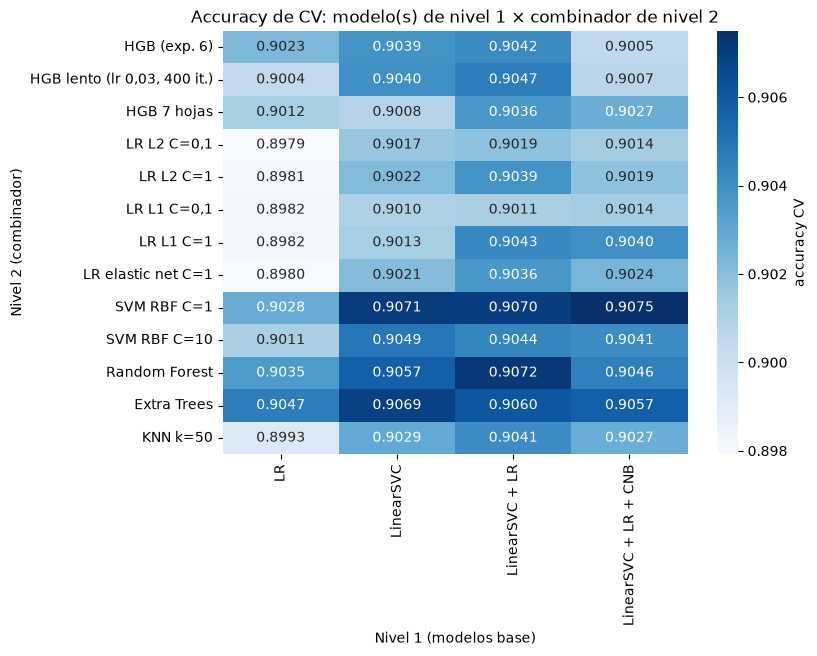

In [10]:
import seaborn as sns

pivote = matriz_modelos.pivot(index="nivel 2", columns="nivel 1", values="acc_cv").reindex(list(NIVEL2))
fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.heatmap(pivote, annot=True, fmt=".4f", cmap="Blues", cbar_kws={"label": "accuracy CV"}, ax=ax)
ax.set_title("Accuracy de CV: modelo(s) de nivel 1 × combinador de nivel 2")
ax.set_xlabel("Nivel 1 (modelos base)")
ax.set_ylabel("Nivel 2 (combinador)")
plt.show()

**Lectura**

- **La fila de control reproduce el experimento 6** (LinearSVC + HGB = 0,9039): la caché no cambia el
  procedimiento.
- **Regresión logística regularizada como combinador no mejora:** con L2, L1 o elastic net y distintos `C` queda entre
  0,898 y 0,904, por debajo o igual que el HGB del experimento 6. Un combinador **lineal** solo puede sumar las
  features, y la ganancia del segundo nivel está en las **interacciones** (polaridad × tipo de conector), que un
  modelo lineal no representa. Tampoco ayuda la L1: con 17–23 features densas no hay features irrelevantes que
  eliminar.
- **Los combinadores no lineales son los mejores:** SVM con kernel RBF (≈ 0,907), Random Forest y Extra Trees
  (≈ 0,906–0,907) superan al HGB (≈ 0,904). Las diferencias entre ellos (≤ 0,002) son mucho menores que la desviación
  entre folds (≈ 0,008).
- **Modelos base de nivel 1:** LinearSVC solo, o combinado con LR, rinde igual; agregar ComplementNB no aporta de
  forma consistente (mejora con el SVM RBF y empeora con HGB), y usar solo LR como base es peor. Los modelos lineales
  base se equivocan casi en las mismas reseñas, así que combinarlos aporta poca diversidad.
- **KNN** (≈ 0,903), que se había descartado sobre TF-IDF, aquí funciona razonablemente: con 17 features densas y
  estandarizadas la distancia sí tiene sentido. Aun así no supera a los demás.

### 2.4 Ajuste fino del SVM RBF y ensambles por votación

Con LinearSVC como nivel 1, se ajustan `C` y `gamma` del SVM RBF de nivel 2 y se prueban ensambles por **votación
suave** (promedio de probabilidades) de los mejores combinadores.

In [11]:
import warnings

# SVC(probability=True) está deprecado en scikit-learn 1.9 (sigue funcionando)
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn.svm")

def svm_rbf(C=1, gamma="scale", probabilidad=False):
    return escalado(SVC(C=C, gamma=gamma, kernel="rbf", probability=probabilidad, random_state=SEED))


def votacion(con_hgb):
    estimadores = [
        ("rbf", svm_rbf(1, probabilidad=True)),
        ("et", ExtraTreesClassifier(n_estimators=500, min_samples_leaf=5, n_jobs=-1, random_state=SEED)),
        ("rf", RandomForestClassifier(n_estimators=500, min_samples_leaf=5, n_jobs=-1, random_state=SEED)),
    ]
    if con_hgb:
        estimadores.append(("hgb", HistGradientBoostingClassifier(max_iter=400, learning_rate=0.03, max_leaf_nodes=15,
                                                                  l2_regularization=1.0, random_state=SEED)))
    return VotingClassifier(estimadores, voting="soft")


AJUSTE = {f"SVM RBF C={C}, gamma={g}": (lambda C=C, g=g: svm_rbf(C, g))
          for C in [0.3, 0.5, 1, 2] for g in ["scale", 0.02, 0.05]}
AJUSTE["Votación RBF + ET + RF"] = lambda: votacion(False)
AJUSTE["Votación RBF + ET + RF + HGB"] = lambda: votacion(True)

acc_ajuste = {nombre: evaluar_cache(f, ["svc"]) for nombre, f in AJUSTE.items()}
ajuste = pd.DataFrame({
    "acc_cv": {k: v.mean() for k, v in acc_ajuste.items()},
    "std": {k: v.std() for k, v in acc_ajuste.items()},
    "folds que gana al exp. 6": {k: int((v > ACC_FOLDS_E6).sum()) for k, v in acc_ajuste.items()},
}).round(4).sort_values("acc_cv", ascending=False)
ajuste

,acc_cv,std,folds que gana al exp. 6
Votación RBF + ET + RF + HGB,0.9077,0.0074,4
Votación RBF + ET + RF,0.9077,0.0093,5
"SVM RBF C=1, gamma=0.05",0.9072,0.0093,4
"SVM RBF C=2, gamma=scale",0.9072,0.0087,4
"SVM RBF C=1, gamma=scale",0.9071,0.0091,4
"SVM RBF C=2, gamma=0.05",0.9070,0.0083,4
"SVM RBF C=0.5, gamma=0.05",0.9059,0.0092,3
"SVM RBF C=0.5, gamma=scale",0.9057,0.0084,4
"SVM RBF C=2, gamma=0.02",0.9057,0.0081,4
"SVM RBF C=0.3, gamma=scale",0.9051,0.0083,4


**Lectura**

- El SVM RBF es estable frente a sus hiperparámetros: con `C` entre 1 y 2 y `gamma` "scale" o 0,05 queda en
  0,9070–0,9072; con `C` bajo (0,3–0,5) o `gamma = 0,02` (frontera más suave) baja a ≈ 0,904.
- Las **votaciones** obtienen 0,9077, prácticamente igual al SVM RBF solo (0,9071); la votación de cuatro modelos tiene
  la menor desviación entre folds (0,0074) y la de tres gana al experimento 6 en los 5 folds.
- Diferencia entre el mejor SVM RBF y la mejor votación: 0,0006, muy por debajo del ruido. Siguiendo la regla del
  proyecto (ante un empate, el modelo más simple), se elige el **SVM RBF con `C = 1`**. Las votaciones quedan
  documentadas como alternativa.

### 2.5 Modelo del experimento 7

**Nivel 1:** LinearSVC (como en el experimento 6). **Nivel 2:** SVM con kernel RBF (`C = 1`, `gamma = "scale"`) sobre
las features estandarizadas. La clase `DosNivelesV2` reproduce exactamente el procedimiento evaluado en la caché
(cross-fitting en `fit`, nivel 1 reentrenado con todos los datos de entrenamiento para predecir).

In [12]:
class DosNivelesV2(BaseEstimator, ClassifierMixin):
    """Stacking del exp. 6 con modelos base y combinador configurables."""

    def __init__(self, bases=("svc",), nivel2=None):
        self.bases = bases
        self.nivel2 = nivel2

    def fit(self, X, y):
        X = pd.Series(list(X))
        y = np.asarray(y)
        F = features_cross_fitting(X, y)
        self.nivel1_ = fit_nivel1(X, y)
        self.nivel2_ = clone(self.nivel2).fit(matriz(F, list(self.bases)), y)
        self.classes_ = self.nivel2_.classes_
        return self

    def predict(self, X):
        X = pd.Series(list(X))
        return self.nivel2_.predict(matriz(features_nivel1(X, self.nivel1_), list(self.bases)))


acc_final = acc_ajuste["SVM RBF C=1, gamma=scale"]
modelo_e7 = DosNivelesV2(bases=("svc",), nivel2=svm_rbf(1, "scale")).fit(X_train, y_train)
print(f"Accuracy CV (caché): {acc_final.mean():.4f} ± {acc_final.std():.4f}")
print(f"Accuracy de entrenamiento: {accuracy_score(y_train, modelo_e7.predict(X_train)):.4f}")

Accuracy CV (caché): 0.9071 ± 0.0091


Accuracy de entrenamiento: 0.9370


Test -> accuracy: 0.9046 | F1 macro: 0.9092

              precision    recall  f1-score   support

    negativo      0.880     0.847     0.863       843
     neutral      0.997     0.999     0.998       715
    positivo      0.851     0.882     0.866       842

    accuracy                          0.905      2400
   macro avg      0.910     0.909     0.909      2400
weighted avg      0.905     0.905     0.905      2400



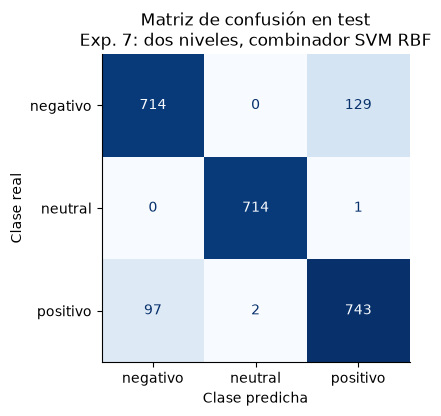

Negativo vs positivo en test: 0.865 (exp. 6: 0,880)


In [13]:
metricas_e7 = evaluar_en_test(modelo_e7, "Exp. 7: dos niveles, combinador SVM RBF")
np_test = (y_test != "neutral").to_numpy()
print(f"Negativo vs positivo en test: {(metricas_e7['pred'][np_test] == y_test.to_numpy()[np_test]).mean():.3f} (exp. 6: 0,880)")

### 2.6 Prueba de robustez en test

In [14]:
def desordenar_oraciones(textos, seed=SEED):
    rng = np.random.default_rng(seed)
    salida = []
    for texto in textos:
        oraciones = dividir_oraciones(texto)
        salida.append(" ".join(rng.permutation(oraciones)) if len(oraciones) > 1 else texto)
    return pd.Series(salida, index=textos.index)


def ultima_al_inicio(textos):
    def mover(texto):
        oraciones = dividir_oraciones(texto)
        return " ".join([oraciones[-1]] + oraciones[:-1])
    return textos.map(mover)


ESCENARIOS = {
    "Original": X_test,
    "Oraciones desordenadas": desordenar_oraciones(X_test),
    "Última oración al inicio": ultima_al_inicio(X_test),
}
filas = [{"modelo": "Exp. 7", "escenario": e, "accuracy": accuracy_score(y_test, modelo_e7.predict(X_e))}
         for e, X_e in ESCENARIOS.items()]
robustez = pd.concat([ROBUSTEZ_TEST_REF, pd.DataFrame(filas)], ignore_index=True)
robustez.pivot(index="escenario", columns="modelo", values="accuracy").reindex(list(ESCENARIOS)).round(4)

modelo,Exp. 2,Exp. 6,Exp. 7
escenario,,,
Original,0.8992,0.9150,0.9046
Oraciones desordenadas,0.6858,0.7354,0.7458
Última oración al inicio,0.5742,0.5921,0.6008


### 2.7 Registro y envío

La CV de este modelo se calculó con la caché (sección 2.4), no con `GridSearchCV`, así que la fila se registra
directamente. `generar_envio` recibe un objeto con el atributo `best_estimator_`, igual que en los demás
experimentos.

In [15]:
from types import SimpleNamespace

resultados.append({
    "experimento": 7,
    "descripcion": "Dos niveles: LinearSVC + polaridad por oración (cross-fitting) -> SVM RBF (C=1)",
    "mejores_params": {"nivel1": "LinearSVC", "nivel2": "SVM RBF C=1"},
    "acc_train": round(accuracy_score(y_train, modelo_e7.predict(X_train)), 4),
    "acc_cv": round(acc_final.mean(), 4),
    "std_cv": round(acc_final.std(), 4),
    "f1_cv": None,
    "acc_test": round(metricas_e7["acc_test"], 4),
    "f1_test": round(metricas_e7["f1_test"], 4),
    "envio": "submission_07.csv",
    "kaggle_publico": None,
})
pd.DataFrame(resultados)

,experimento,descripcion,mejores_params,acc_train,acc_cv,std_cv,f1_cv,acc_test,f1_test,envio,kaggle_publico
0,1,"Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",{'clf__C': 10},0.9973,0.7364,0.0128,0.7478,0.7238,0.7366,submission_01.csv,NaN
1,2,"TF-IDF (1,2) de texto completo + última oración + tras el último conector + LR",{'clf__C': 10},0.9999,0.8865,0.0099,0.8908,0.8992,0.9031,submission_02.csv,0.88
2,3,"TF-IDF (1,2) de texto completo + oraciones con conector conclusivo + LR (sin posición)",{'clf__C': 10},0.9980,0.7978,0.0146,0.8064,0.7963,0.8054,submission_03.csv,NaN
3,4,"Texto completo + última oración con opinión (detector) + tras conector sin evasivas, LinearSVC","{'clf': 'LinearSVC', 'clf__C': 0.2}",0.9770,0.9009,0.0057,0.9055,0.8975,0.9021,submission_04.csv,NaN
4,5,"Como el exp. 4, con el detector de opinión aplicado a la oración sin su conector inicial","{'clf': 'LinearSVC', 'clf__C': 0.2}",0.9773,0.9022,0.0080,0.9068,0.9021,0.9068,submission_05.csv,NaN
5,6,Dos niveles: modelo del exp. 5 + polaridad por oración (cross-fitting) -> HistGradientBoosting,{'nivel2': 'hgb'},0.9392,0.9039,0.0102,0.9085,0.9150,0.9191,submission_06.csv,0.90
6,7,Dos niveles: LinearSVC + polaridad por oración (cross-fitting) -> SVM RBF (C=1),"{'nivel1': 'LinearSVC', 'nivel2': 'SVM RBF C=1'}",0.9370,0.9071,0.0091,NaN,0.9046,0.9092,submission_07.csv,NaN


In [16]:
envio_e7 = generar_envio(SimpleNamespace(best_estimator_=modelo_e7), numero=7)

Envío guardado en envios/submission_07.csv y modelo en modelos/modelo_07.joblib
Distribución de predicciones en eval (%):
answer
negativo    36.1
neutral     27.6
positivo    36.3


### 2.8 Análisis del experimento 7

**Resultados:** accuracy de CV = **0,9071 ± 0,0091** (gana al experimento 6 en 4 de 5 folds) y accuracy en
test = **0,9046**.

| | Exp. 5 | Exp. 6 | Exp. 7 |
|---|---|---|---|
| Accuracy CV | 0,9022 | 0,9039 | **0,9071** |
| Accuracy de entrenamiento | 0,9773 | 0,9392 | 0,9370 |
| Accuracy test | 0,9021 | **0,9150** | 0,9046 |
| Negativo vs positivo (test) | 0,861 | **0,880** | 0,865 |
| Test, oraciones desordenadas | 0,738 | 0,735 | **0,746** |
| Test, última oración al inicio | 0,595 | 0,592 | **0,601** |

1. **La CV y el test se contradicen:** según la CV, el experimento 7 es el mejor (+0,32 puntos sobre el 6); según el
   test, el experimento 6 es mejor (+1,04 puntos, ≈ 25 reseñas). Ambas diferencias son pequeñas frente a la
   incertidumbre: la de CV está dentro de la desviación entre folds y la del test equivale a ≈ 1,7 errores estándar
   de una sola partición de 2.400 reseñas, en la que ≈ 11 % de las etiquetas son prácticamente aleatorias. La
   conclusión honesta es que **los experimentos 6 y 7 están empatados**: el cambio de combinador no produce una
   mejora clara.
2. **Variar el clasificador no rompe la meseta:** de las ≈ 50 combinaciones de modelos probadas, todas las razonables
   quedan entre 0,900 y 0,908 de CV. La regresión logística regularizada (L1, L2, elastic net) como combinador no
   mejora, porque la ganancia del segundo nivel viene de interacciones no lineales.
3. **Es consistente con el techo estimado** (≈ 0,937, experimento 5): con ≈ 11–13 % de etiquetas casi aleatorias, el
   margen restante es pequeño y difícil de distinguir del ruido de la evaluación. Por la misma razón, diferencias de
   ±0,01 en el leaderboard público (por ejemplo, 0,90 frente a 0,91) no indican necesariamente un modelo mejor.
4. **Robustez:** ligeramente mejor que la del experimento 6, pero igual de dependiente de la posición.

**Decisión:** se genera `submission_07.csv` (SVM RBF) como alternativa al experimento 6. Como ambos están empatados,
**para elegir el modelo final conviene combinar todas las señales disponibles** (CV, test y score público de ambos
envíos) y, ante la duda, preferir el de menor varianza. Si se quisiera un modelo más estable para la entrega, la
votación RBF + ET + RF + HGB (0,9077 ± 0,0074 en CV) es la opción natural.